In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [21]:

## Create data
nPerClust = 50

# blur around centroid (std units)
blur = 1

# XY centroid locations
A = [  1, 1 ]
B = [ -3, 1 ]
C = [  3, 3 ]

# generate data
a = [ A[0]+np.random.randn(nPerClust)*blur , A[1]+np.random.randn(nPerClust)*blur ]
b = [ B[0]+np.random.randn(nPerClust)*blur , B[1]+np.random.randn(nPerClust)*blur ]
c = [ C[0]+np.random.randn(nPerClust)*blur , C[1]+np.random.randn(nPerClust)*blur ]

# concatanate into a matrix
data = np.transpose( np.concatenate((a,b,c),axis=1) )
data

array([[ 0.88635961,  1.24641605],
       [ 0.64194793,  2.31837923],
       [ 1.90109766, -0.25906385],
       [ 2.00695418,  1.55665924],
       [ 2.00790831,  0.45886622],
       [ 2.23662229,  2.36313993],
       [ 0.5366499 ,  2.6846161 ],
       [ 1.6306941 , -1.629327  ],
       [ 1.33133825,  1.8811911 ],
       [ 1.42403741,  1.48131625],
       [ 2.27125011,  0.44203419],
       [ 0.5578279 ,  1.04140381],
       [ 0.47111944,  1.82983611],
       [ 2.61539174,  1.08208022],
       [ 0.18500987,  2.0748156 ],
       [ 1.68712229,  0.08410922],
       [ 0.74468184,  1.37321362],
       [ 1.92991935,  1.54876051],
       [ 0.21330344,  3.02823419],
       [ 1.98443022,  1.64815755],
       [ 0.68297998,  0.73131621],
       [ 2.80033735,  0.77774073],
       [ 0.8075087 ,  0.81282175],
       [ 3.31068267,  1.59497509],
       [ 2.57722792,  1.30957746],
       [ 1.83304756,  1.47142083],
       [ 1.14709899, -0.03429632],
       [ 0.16816708,  2.2074101 ],
       [ 2.1165007 ,

In [51]:
iterations = 5
centers = []
## initialize random cluster centroids
k = 3 # extract three clusters

for _ in range(iterations):
    # random cluster centers (randomly sampled data points)
    ridx = np.random.choice(range(len(data)),k,replace=False)
    centroids = data[ridx,:]
    centers.append(centroids)

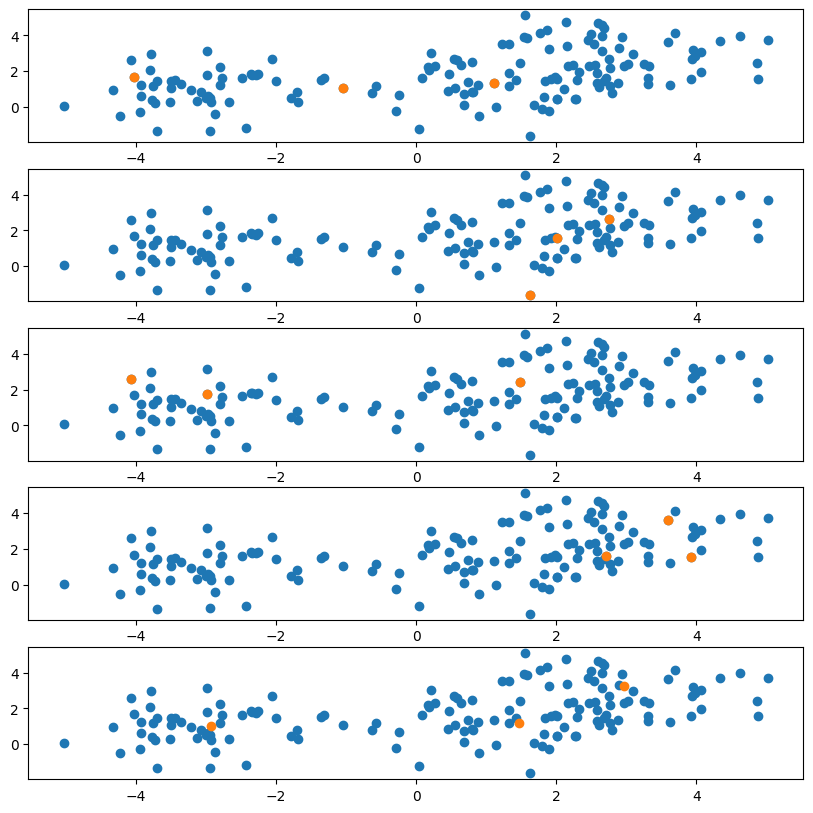

In [54]:

fig, axes = plt.subplots(nrows=iterations, figsize=(10,10))
for i, c in enumerate(centers):
    x, y = c[:,0], c[:,1]
    axes[i].scatter(x=data[:,0], y=data[:,1])
    axes[i].scatter(x=x, y=y)

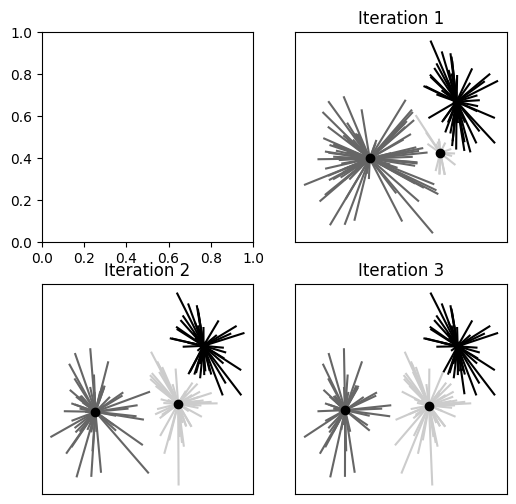

In [53]:
# copy pasta from github for book
new_k = 3

fig,axs = plt.subplots(2,2,figsize=(6,6))
axs = axs.flatten()
lineColors = [ [0,0,0],[.4,.4,.4],[.8,.8,.8] ]#'rbm'

# loop over iterations
for iteri in range(3):

  # step 1: compute distances
  dists = np.zeros((data.shape[0],new_k))
  for ci in range(new_k):
    dists[:,ci] = np.sum((data-centroids[ci,:])**2,axis=1)

  # step 2: assign to group based on minimum distance
  groupidx = np.argmin(dists,axis=1)

  # step 3: recompute centers
  for ki in range(new_k):
    centroids[ki,:] = [ np.mean(data[groupidx==ki,0]), np.mean(data[groupidx==ki,1]) ]


  # plot data points
  for i in range(len(data)):
    axs[iteri+1].plot([ data[i,0],centroids[groupidx[i],0] ],[ data[i,1],centroids[groupidx[i],1] ],color=lineColors[groupidx[i]])
  axs[iteri+1].plot(centroids[:,0],centroids[:,1],'ko')
  axs[iteri+1].set_title(f'Iteration {iteri+1}')
  axs[iteri+1].set_xticks([])
  axs[iteri+1].set_yticks([])